# 02 — Entrenamiento EfficientNet-B0 (PyTorch Lightning)

**Para el informe / revisión docente:** este notebook entrena el clasificador de 38 clases y deja **tabla y gráficas** de cada época:

- `train_loss` / `val_loss` (error)
- `train_acc` / `val_acc` (precisión)

**Requisitos:** GPU recomendada (Lightning Studio o Kaggle). En CPU tarda mucho.

**Modo rápido (`FAST_MODE=True`):** 50 imágenes por clase, 10 épocas (~30–60 min en GPU).

Salidas guardadas en `notebooks/training_outputs/`.

## 1. Entorno y rutas

In [1]:
%pip install -q pytorch-lightning torchmetrics torchvision wandb python-dotenv tqdm

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import pytorch_lightning as pl
import torch
from pytorch_lightning.callbacks import Callback, EarlyStopping, ModelCheckpoint

PROJECT_ROOT = Path("/teamspace/studios/this_studio/plant-disease-detector")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datamodule import PlantDiseaseDataModule
from src.model import PlantDiseaseModule

OUT_DIR = PROJECT_ROOT / "notebooks" / "training_outputs"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

pl.seed_everything(42)
DEVICE = "GPU" if torch.cuda.is_available() else "CPU"
print("Proyecto:", PROJECT_ROOT)
print("Dispositivo:", DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

Note: you may need to restart the kernel to use updated packages.


Seed set to 42


Proyecto: /teamspace/studios/this_studio/plant-disease-detector
Dispositivo: GPU NVIDIA L4


## 2. Configuración del entrenamiento

In [2]:
# True = demo/informe (rápido). False = dataset completo (varias horas).
FAST_MODE = True

if FAST_MODE:
    MAX_PER_CLASS = 50
    MAX_EPOCHS = 10
    FREEZE_EPOCHS = 2
    BATCH_SIZE = 32
else:
    MAX_PER_CLASS = None
    MAX_EPOCHS = 15
    FREEZE_EPOCHS = 3
    BATCH_SIZE = 32

NUM_WORKERS = 2 if DEVICE == "CPU" else 4
WANDB_OFF = True  # False si hiciste wandb login y quieres dashboard online

print(f"Modo: {'rápido' if FAST_MODE else 'completo'}")
print(f"Épocas: {MAX_EPOCHS} | Congelar backbone: {FREEZE_EPOCHS} épocas iniciales")

Modo: rápido
Épocas: 10 | Congelar backbone: 2 épocas iniciales


## 3. Localizar o descargar datos

In [3]:
def find_data_dir():
    candidates = [
        PROJECT_ROOT / "data" / "plantvillage",
        Path("data/plantvillage"),
    ]
    for base in [Path("/kaggle/input"), Path("/teamspace")]:
        if base.exists():
            for root, dirs, _ in os.walk(base):
                if "train" in dirs and "valid" in dirs:
                    return Path(root)
                if len(root.split(os.sep)) > 14:
                    break
    for c in candidates:
        if (c / "train").is_dir() and (c / "valid").is_dir():
            return c
    return None

DATA_DIR = find_data_dir()
if DATA_DIR is None:
    print("No hay carpetas train/valid. Descargando subset desde Hugging Face...")
    import subprocess
    out = PROJECT_ROOT / "data" / "plantvillage"
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "download_dataset_hf.py"),
        "--out",
        str(out),
    ]
    if FAST_MODE:
        cmd += ["--max-per-class", str(MAX_PER_CLASS)]
    subprocess.run(cmd, check=True, cwd=PROJECT_ROOT)
    DATA_DIR = out

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /teamspace/studios/this_studio/plant-disease-detector-aws/data/plantvillage


## 4. Callback para guardar métricas por época

In [4]:
class EpochMetricsCallback(Callback):
    """Acumula train/val loss y accuracy al final de cada época (para tablas y gráficas)."""

    def __init__(self) -> None:
        self.history: list[dict] = []

    def on_validation_epoch_end(self, trainer, pl_module) -> None:
        m = trainer.callback_metrics
        row = {
            "epoch": int(trainer.current_epoch),
            "train_loss": float(m.get("train_loss", float("nan"))),
            "train_acc": float(m.get("train_acc", float("nan"))),
            "val_loss": float(m.get("val_loss", float("nan"))),
            "val_acc": float(m.get("val_acc", float("nan"))),
        }
        self.history.append(row)
        print(
            f"Época {row['epoch']+1:02d}/{trainer.max_epochs} | "
            f"train loss={row['train_loss']:.4f} acc={row['train_acc']:.4f} | "
            f"val loss={row['val_loss']:.4f} acc={row['val_acc']:.4f}"
        )

metrics_cb = EpochMetricsCallback()

## 5. Entrenar

In [5]:
dm = PlantDiseaseDataModule(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    max_samples_per_class=MAX_PER_CLASS,
)
dm.setup()
num_classes = len(dm.class_to_idx)
mapping_path = CKPT_DIR / "class_mapping.json"
dm.save_class_mapping(mapping_path)
print(f"Clases: {num_classes} | Mapeo: {mapping_path}")

model = PlantDiseaseModule(num_classes=num_classes, freeze_epochs=FREEZE_EPOCHS)

checkpoint_cb = ModelCheckpoint(
    dirpath=str(CKPT_DIR),
    filename="efficientnet-{epoch:02d}-{val_acc:.4f}",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
)
early_stop = EarlyStopping(monitor="val_acc", patience=4, mode="max")

if WANDB_OFF:
    logger = pl.loggers.TensorBoardLogger(str(OUT_DIR), name="tensorboard")
else:
    from pytorch_lightning.loggers import WandbLogger
    logger = WandbLogger(project="plant-disease-eafit", log_model=False)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=32,
    callbacks=[checkpoint_cb, early_stop, metrics_cb],
    logger=logger,
    log_every_n_steps=10,
    enable_progress_bar=True,
)

trainer.fit(model, datamodule=dm)

best_ckpt = checkpoint_cb.best_model_path
print("\n✓ Mejor checkpoint:", best_ckpt)
print("  val_acc:", checkpoint_cb.best_model_score)

Clases: 38 | Mapeo: /teamspace/studios/this_studio/plant-disease-detector/checkpoints/class_mapping.json


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/plant-disease-detector/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Época 08/10 | train loss=0.0953 acc=0.9858 | val loss=0.1309 acc=0.9597

Época 09/10 | train loss=0.1021 acc=0.9937 | val loss=0.1333 acc=0.9604

Época 10/10 | train loss=0.1090 acc=0.9942 | val loss=0.1332 acc=0.9616

`Trainer.fit` stopped: `max_epochs=10` reached.



✓ Mejor checkpoint: /teamspace/studios/this_studio/plant-disease-detector/checkpoints/efficientnet-epoch=09-val_acc=0.9616.ckpt
  val_acc: tensor(0.9616, device='cuda:0')


## 6. Tabla de métricas por época

In [6]:
history_df = pd.DataFrame(metrics_cb.history)
history_df["epoch"] = history_df["epoch"] + 1  # 1-based para el informe
history_df = history_df.rename(
    columns={
        "train_loss": "error_train",
        "val_loss": "error_valid",
        "train_acc": "acc_train",
        "val_acc": "acc_valid",
    }
)

display(history_df.round(4))

history_path = OUT_DIR / "historial_entrenamiento.json"
history_df.to_json(history_path, orient="records", indent=2, force_ascii=False)
history_df.to_csv(OUT_DIR / "historial_entrenamiento.csv", index=False)
print("Guardado:", history_path)

,epoch,error_train,acc_train,error_valid,acc_valid
0,1,NaN,NaN,3.5480,0.0000
1,1,2.2122,NaN,1.9856,0.7724
2,2,1.2818,0.4158,1.1952,0.8407
3,3,0.3179,0.7995,0.3829,0.9105
4,4,0.2755,0.8747,0.2469,0.9391
5,5,0.1316,0.9474,0.1957,0.9438
6,6,0.0560,0.9695,0.1623,0.9512
7,7,0.0719,0.9784,0.1459,0.9537
8,8,0.0953,0.9858,0.1309,0.9597
9,9,0.1021,0.9937,0.1333,0.9604


Guardado: /teamspace/studios/this_studio/plant-disease-detector/notebooks/training_outputs/historial_entrenamiento.json


## 7. Gráficas (error y accuracy)

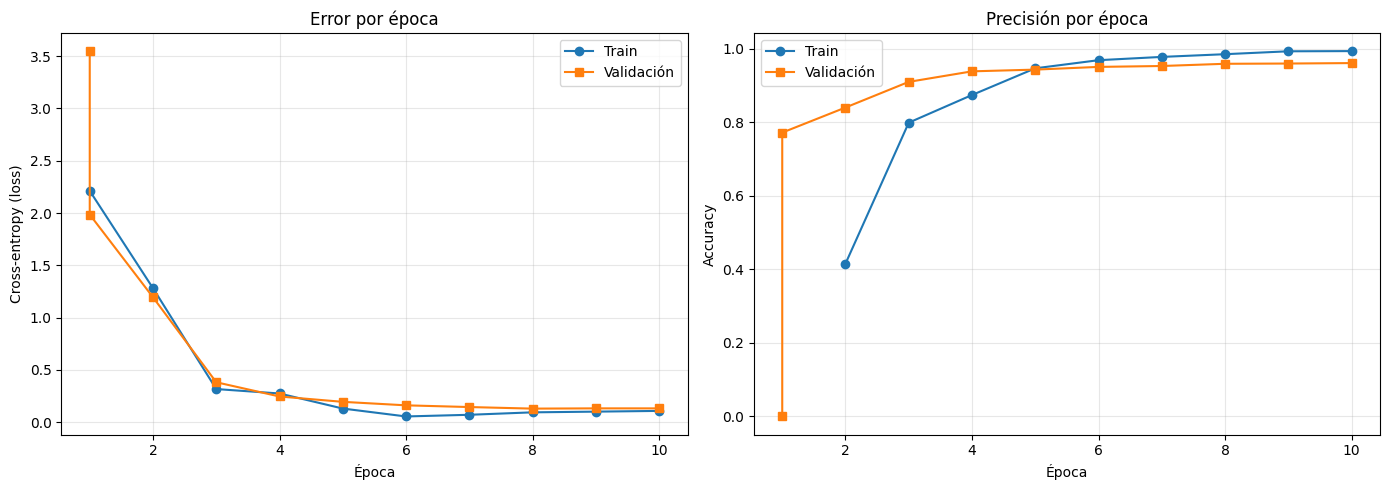

Figura: /teamspace/studios/this_studio/plant-disease-detector/notebooks/training_outputs/curvas_entrenamiento.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = history_df["epoch"]

axes[0].plot(epochs, history_df["error_train"], marker="o", label="Train")
axes[0].plot(epochs, history_df["error_valid"], marker="s", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cross-entropy (loss)")
axes[0].set_title("Error por época")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_df["acc_train"], marker="o", label="Train")
axes[1].plot(epochs, history_df["acc_valid"], marker="s", label="Validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Precisión por época")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / "curvas_entrenamiento.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Figura:", fig_path)

## 8. Resumen para el informe

In [8]:
best_row = history_df.loc[history_df["acc_valid"].idxmax()]
print("=" * 60)
print("RESUMEN ENTRENAMIENTO — EfficientNet-B0")
print("=" * 60)
print(f"Dataset:        {DATA_DIR}")
print(f"Modo:           {'rápido (subset)' if FAST_MODE else 'completo'}")
print(f"Épocas corridas: {len(history_df)}")
print(f"Mejor época:    {int(best_row['epoch'])} (val_acc = {best_row['acc_valid']:.4f})")
print(f"Checkpoint:     {best_ckpt}")
print("=" * 60)
print("Siguiente paso: exportar ONNX con")
print(f"  python -m src.export_onnx --checkpoint {best_ckpt} --class_mapping {mapping_path}")

RESUMEN ENTRENAMIENTO — EfficientNet-B0
Dataset:        /teamspace/studios/this_studio/plant-disease-detector-aws/data/plantvillage
Modo:           rápido (subset)
Épocas corridas: 11
Mejor época:    10 (val_acc = 0.9616)
Checkpoint:     /teamspace/studios/this_studio/plant-disease-detector/checkpoints/efficientnet-epoch=09-val_acc=0.9616.ckpt
Siguiente paso: exportar ONNX con
  python -m src.export_onnx --checkpoint /teamspace/studios/this_studio/plant-disease-detector/checkpoints/efficientnet-epoch=09-val_acc=0.9616.ckpt --class_mapping /teamspace/studios/this_studio/plant-disease-detector/checkpoints/class_mapping.json


---

### Notas para el profesor

| Archivo | Contenido |
|---------|------------|
| `notebooks/01_EDA_executed.ipynb` | Exploración del dataset |
| **`notebooks/02_entrenamiento.ipynb`** | **Este notebook — métricas por época** |
| `checkpoints/*.ckpt` | Mejor modelo guardado por Lightning |
| `notebooks/training_outputs/historial_entrenamiento.csv` | Tabla exportada |

Proyecto AWS (ResNet-50 en servidor): ver `plant-disease-detector-aws` y `pipeline.log` en Lightning Studio.